In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')
print(df.shape) #dimensions
print(df.columns) #coloumn headers
print(df.head()) #first 5 rows

(13320, 9)
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [5]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
#cleaning size coloumn
df['size'].value_counts()


size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [7]:
df['bhk'] = df['size'].str.extract('(\d+)').astype(float)

In [8]:
df[['size','bhk']].head(20)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [9]:
#cleaning total_sqft
df['total_sqft'].unique()[:50]
#problem - its stored as text, and at

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
        '1800',        '2785',        '1000',        '1100',        '2250',
        '1175',        '1180',        '1540',        '2770',         '600',
        '1755',        '2800',        '1767',         '510',        '1250',
         '660',        '1610',        '1151',        '1025', '2100 - 2850',
        '1075',        '1760',        '1693',        '1925',         '700',
        '1070',        '1724',        '1290',        '1143',        '1296',
        '1254',     '1330.74',         '970',        '1459',         '800',
         '869',        '1270',        '1670',        '2010',        '1185']
Length: 50, dtype: str

In [10]:
import re

def convert_sqft(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        # 1. Ranges: "2100 - 2850"
        if '-' in value:
            parts = value.split('-')

            if len(parts) == 2:
                low = float(parts[0].strip())
                high = float(parts[1].strip())
                return (low + high) / 2

        # 2. Acres
        match = re.match(r'([\d.]+)\s*Acres?', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 43560

        # 3. Square yards
        match = re.match(r'([\d.]+)\s*Sq\.?\s*Yards?', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 9

        # 4. Square meters
        match = re.match(r'([\d.]+)\s*Sq\.?\s*Meter', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 10.7639

        # 5. Cents
        match = re.match(r'([\d.]+)\s*Cents?', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 435.6

        # 6. Gunta / Guntha
        match = re.match(r'([\d.]+)\s*Gunt(?:a|ha)', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 1089

        # 7. Ground
        match = re.match(r'([\d.]+)\s*Grounds?', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 2400

        # 8. Perch
        match = re.match(r'([\d.]+)\s*Perch', value, re.IGNORECASE)
        if match:
            return float(match.group(1)) * 272.25

        # 9. Normal number
        return float(value)

    except (ValueError, TypeError):
        return np.nan

In [11]:
df[~df['total_sqft'].str.match(r'^\d+(\.\d+)?$', na=False)]['total_sqft'].value_counts()

total_sqft
2830 - 2882          5
1200 - 2400          3
3630 - 3800          3
2249.81 - 4112.19    3
4000 - 5249          2
                    ..
1437 - 1629          1
850 - 1060           1
1200 - 1470          1
1020 - 1130          1
1133 - 1384          1
Name: count, Length: 222, dtype: int64

In [12]:
df['total_sqft_clean'] = df['total_sqft'].apply(convert_sqft)

In [13]:
print("Unconverted values:", df['total_sqft_clean'].isna().sum())

Unconverted values: 0


In [14]:
df[df['total_sqft_clean'].isna()][['total_sqft']]

,total_sqft


In [15]:
df['total_sqft'] = df['total_sqft_clean']
df.drop(columns=['total_sqft_clean'], inplace=True)

In [16]:
df[['total_sqft']].head()

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0


In [17]:
df['total_sqft'].dtype

dtype('float64')

In [18]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
bhk               16
dtype: int64

In [19]:
df = df.dropna(subset=['location']).copy()

In [20]:
df['location'] = df['location'].str.strip()

In [21]:
df['location'].isna().sum()

np.int64(0)

In [22]:
df['bhk'].isna().sum()

np.int64(16)

In [23]:
df = df.dropna(subset=['bhk']).copy()

In [24]:
df = df.drop(columns=['size'])

In [25]:
df['bhk'].isna().sum()

np.int64(0)

In [26]:
df = df.drop(columns=['society'])

In [27]:
df = df.drop(columns=['availability'])

In [28]:
df['bath'] = (
    df.groupby('bhk')['bath']
      .transform(lambda x: x.fillna(x.median()))
)

In [29]:
df['bath'] = df['bath'].fillna(df['bath'].median())

In [30]:
df['bath'].isna().sum()

np.int64(0)

In [31]:
df['balcony'] = (
    df.groupby('bhk')['balcony']
      .transform(lambda x: x.fillna(x.median()))
)

df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [32]:
df['balcony'] = df['balcony'].round().astype(int)

In [33]:
df['balcony'].isna().sum()

np.int64(0)

In [34]:
df.isna().sum()

area_type     0
location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

In [35]:
print("Invalid BHK:", (df['bhk'] <= 0).sum())
print("Invalid sqft:", (df['total_sqft'] <= 0).sum())
print("Invalid bath:", (df['bath'] <= 0).sum())
print("Invalid price:", (df['price'] <= 0).sum())

Invalid BHK: 0
Invalid sqft: 0
Invalid bath: 0
Invalid price: 0


In [36]:
print("Shape:", df.shape)

Shape: (13303, 7)


In [37]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1,51.00,2.0


In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 13303 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13303 non-null  str    
 1   location    13303 non-null  str    
 2   total_sqft  13303 non-null  float64
 3   bath        13303 non-null  float64
 4   balcony     13303 non-null  int64  
 5   price       13303 non-null  float64
 6   bhk         13303 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 1.2 MB


In [39]:
# Phase 2 — Exploratory Data Analysis (EDA)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 13303
Columns: 7


,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1,51.00,2.0


In [40]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,1.330300e+04,13303.000000,13303.000000,13303.000000,13303.000000
mean,1.911232e+03,2.694881,1.599564,112.584033,2.803728
std,1.728790e+04,1.340770,0.804993,148.993820,1.295022
min,1.000000e+00,1.000000,0.000000,8.000000,1.000000
25%,1.100000e+03,2.000000,1.000000,50.000000,2.000000
50%,1.276000e+03,2.000000,2.000000,72.000000,3.000000
75%,1.680000e+03,3.000000,2.000000,120.000000,3.000000
max,1.306800e+06,40.000000,3.000000,3600.000000,43.000000


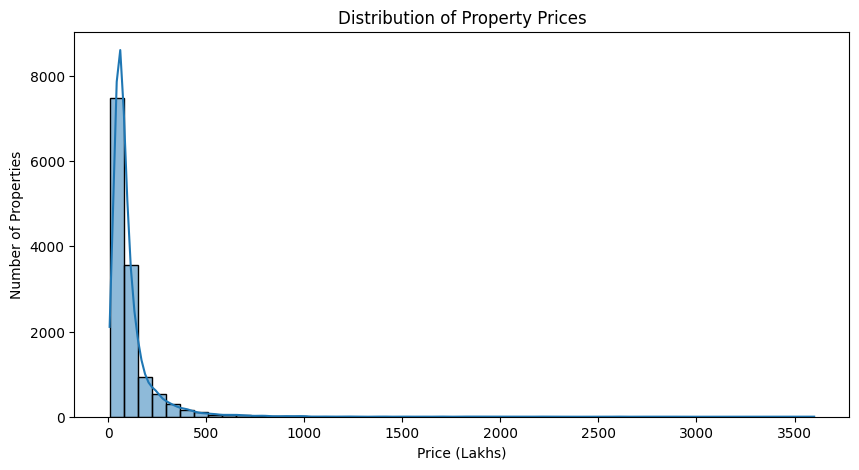

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Number of Properties')
plt.show()

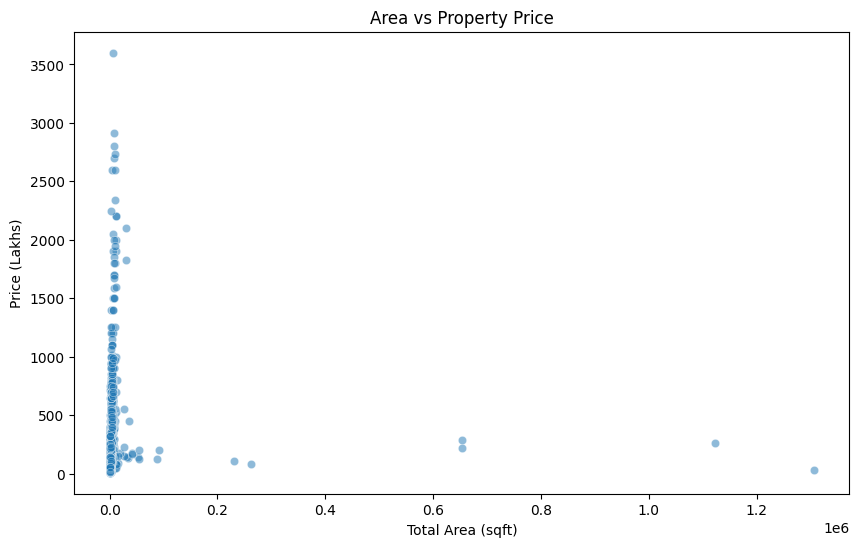

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='total_sqft',
    y='price',
    alpha=0.5
)
plt.title('Area vs Property Price')
plt.xlabel('Total Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.show()

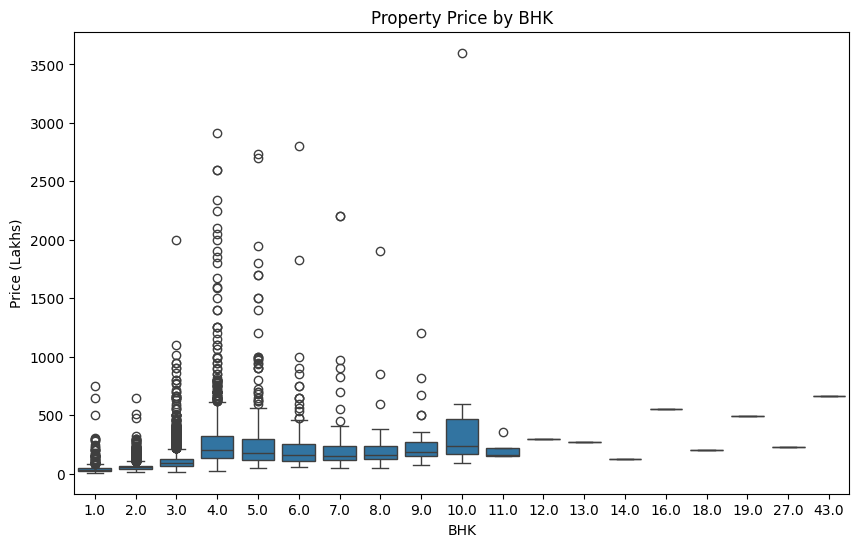

In [43]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bhk', y='price')
plt.title('Property Price by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

In [44]:
df['bhk'].value_counts().sort_index()

bhk
1.0      656
2.0     5528
3.0     4856
4.0     1417
5.0      356
6.0      221
7.0      100
8.0       89
9.0       54
10.0      14
11.0       4
12.0       1
13.0       1
14.0       1
16.0       1
18.0       1
19.0       1
27.0       1
43.0       1
Name: count, dtype: int64

In [45]:
location_stats = df.groupby('location').agg(
    property_count=('price', 'count'),
    median_price=('price', 'median'),
    median_sqft=('total_sqft', 'median')
).reset_index()

In [46]:
location_stats[
    location_stats['property_count'] >= 20
].sort_values('median_price', ascending=False).head(20)

,location,property_count,median_price,median_sqft
771,Malleshwaram,58,261.0,2215.0
962,Rajaji Nagar,107,250.0,1720.0
29,2nd Stage Nagarbhavi,24,236.5,1200.0
544,Iblur Village,25,220.0,2987.5
414,Frazer Town,36,210.0,2039.5
548,Indira Nagar,44,195.5,1675.0
881,Old Airport Road,33,194.0,2690.0
500,Hebbal Kempapura,34,167.5,1727.5
15,1st Phase JP Nagar,25,167.0,1566.0
525,Hosakerehalli,36,150.0,1871.0


In [47]:
df['price_per_sqft'] = (
    df['price'] * 100000 / df['total_sqft']
)

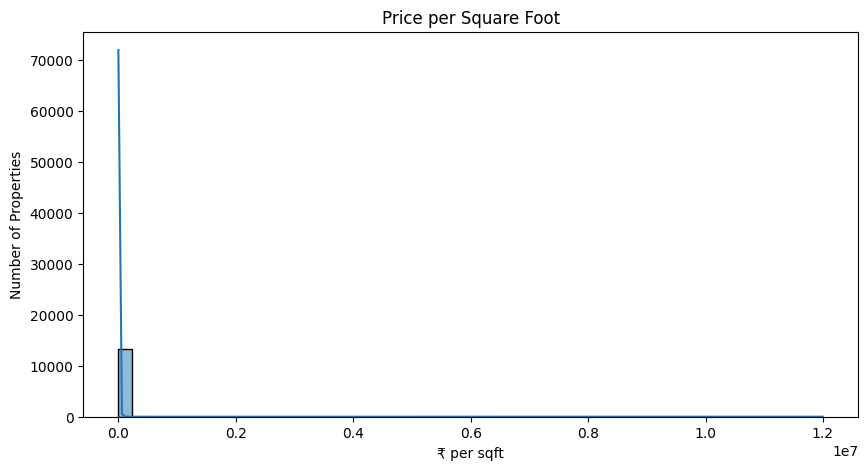

In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price_per_sqft'], bins=50, kde=True)
plt.title('Price per Square Foot')
plt.xlabel('₹ per sqft')
plt.ylabel('Number of Properties')
plt.show()

In [49]:
df.nlargest(15, 'price_per_sqft')[
    ['location', 'bhk', 'total_sqft', 'price', 'price_per_sqft']
]

,location,bhk,total_sqft,price,price_per_sqft
4086,Sarjapur Road,4.0,1.0,120.0,1.200000e+07
4972,Srirampuram,7.0,5.0,115.0,2.300000e+06
349,Suragajakkanahalli,3.0,11.0,74.0,6.727273e+05
1122,Grihalakshmi Layout,5.0,24.0,150.0,6.250000e+05
11558,Whitefield,4.0,60.0,218.0,3.633333e+05
1020,Weavers Colony,1.0,15.0,30.0,2.000000e+05
7657,Raghuvanahalli,1.0,425.0,750.0,1.764706e+05
5668,Judicial Layout,5.0,405.0,400.0,9.876543e+04
7088,Srirampuram,1.0,650.0,500.0,7.692308e+04
6421,Bommenahalli,4.0,2940.0,2250.0,7.653061e+04


In [50]:
df.nsmallest(15, 'price_per_sqft')[
    ['location', 'bhk', 'total_sqft', 'price', 'price_per_sqft']
]

,location,bhk,total_sqft,price,price_per_sqft
1086,Narasapura,2.0,1306800.00,29.5,2.257423
648,Arekere,9.0,1123031.25,265.0,23.596850
11615,arudi,3.0,261360.00,80.0,30.609122
7607,Bommenahalli,3.0,653400.00,217.0,33.210897
7001,Thyagaraja Nagar,8.0,653400.00,290.0,44.383226
1019,Marathi Layout,1.0,231303.60,110.0,47.556545
7334,Kanakpura Road,1.0,87120.00,125.0,143.480257
6333,Harohalli,2.0,91040.40,200.0,219.682690
7726,Kanakpura Road,1.0,54885.60,125.0,227.746440
1894,Nelamangala,3.0,52272.00,140.0,267.829813


In [51]:
df.nlargest(15, 'total_sqft')[
    ['location', 'bhk', 'total_sqft', 'bath', 'price']
]

,location,bhk,total_sqft,bath,price
1086,Narasapura,2.0,1306800.00,2.0,29.5
648,Arekere,9.0,1123031.25,9.0,265.0
7001,Thyagaraja Nagar,8.0,653400.00,6.0,290.0
7607,Bommenahalli,3.0,653400.00,3.0,217.0
11615,arudi,3.0,261360.00,2.0,80.0
1019,Marathi Layout,1.0,231303.60,1.0,110.0
6333,Harohalli,2.0,91040.40,2.0,200.0
7334,Kanakpura Road,1.0,87120.00,1.0,125.0
7726,Kanakpura Road,1.0,54885.60,1.0,125.0
10488,2 Bedroom Furnished Farm House in Kolar Road,2.0,54450.00,2.0,200.0


In [52]:
df.nlargest(15, 'bath')[
    ['location', 'bhk', 'total_sqft', 'bath', 'price']
]

,location,bhk,total_sqft,bath,price
4684,Munnekollal,43.0,2400.0,40.0,660.0
1718,2Electronic City Phase II,27.0,8000.0,27.0,230.0
11559,1Kasavanhalli,18.0,1200.0,18.0,200.0
3379,1Hanuman Nagar,19.0,2000.0,16.0,490.0
3609,Koramangala Industrial Layout,16.0,10000.0,16.0,550.0
4916,1Channasandra,14.0,1250.0,15.0,125.0
1078,BTM 1st Stage,9.0,3300.0,14.0,500.0
9935,1Hoysalanagar,13.0,5425.0,13.0,275.0
10695,Electronic City,9.0,1200.0,13.0,150.0
13067,Defence Colony,10.0,7150.0,13.0,3600.0


In [53]:
df.nlargest(15, 'price')[
    ['location', 'bhk', 'total_sqft', 'bath', 'price']
]

,location,bhk,total_sqft,bath,price
13067,Defence Colony,10.0,7150.0,13.0,3600.0
11080,Ashok Nagar,4.0,8321.0,5.0,2912.0
13200,Defence Colony,6.0,8000.0,6.0,2800.0
11763,Sadashiva Nagar,5.0,9600.0,7.0,2736.0
3180,Shanthala Nagar,5.0,8321.0,5.0,2700.0
12443,Dollars Colony,4.0,4350.0,8.0,2600.0
13197,Ramakrishnappa Layout,4.0,9200.0,4.0,2600.0
10304,5th Block Jayanagar,4.0,10624.0,4.0,2340.0
6421,Bommenahalli,4.0,2940.0,3.0,2250.0
408,Rajaji Nagar,7.0,12000.0,6.0,2200.0


In [54]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

In [55]:
df = df[df['sqft_per_bhk'] >= 300].copy()

In [56]:
df = df[(df['bhk'] >= 1) & (df['bhk'] <= 10)].copy()

In [57]:
df[df['total_sqft'] > 20000][
    ['area_type', 'location', 'bhk', 'total_sqft', 'price']
].sort_values('total_sqft', ascending=False).head(30)

,area_type,location,bhk,total_sqft,price
1086,Plot Area,Narasapura,2.0,1306800.000,29.5
648,Built-up Area,Arekere,9.0,1123031.250,265.0
7001,Plot Area,Thyagaraja Nagar,8.0,653400.000,290.0
7607,Plot Area,Bommenahalli,3.0,653400.000,217.0
11615,Plot Area,arudi,3.0,261360.000,80.0
1019,Plot Area,Marathi Layout,1.0,231303.600,110.0
6333,Plot Area,Harohalli,2.0,91040.400,200.0
7334,Plot Area,Kanakpura Road,1.0,87120.000,125.0
7726,Plot Area,Kanakpura Road,1.0,54885.600,125.0
10488,Plot Area,2 Bedroom Furnished Farm House in Kolar Road,2.0,54450.000,200.0


In [58]:
df[df['total_sqft'] > 20000]['area_type'].value_counts()

area_type
Plot  Area              15
Built-up  Area           4
Super built-up  Area     2
Name: count, dtype: int64

In [59]:
df = df[df['area_type'].isin([
    'Built-up  Area',
    'Super built-up  Area'
])].copy()

In [60]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8735
Built-up  Area          2349
Name: count, dtype: int64

In [61]:
df = df[df['total_sqft'] <= 20000].copy()

In [62]:
print(df.shape)
print(df['total_sqft'].max())

(11078, 9)
16335.0


In [63]:
df['location'] = (
    df['location']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [64]:
df['location'].value_counts().head(20)

location
Whitefield                  456
Sarjapur Road               367
Electronic City             287
Kanakpura Road              255
Thanisandra                 233
Yelahanka                   195
Uttarahalli                 175
Hebbal                      169
Marathahalli                164
Raja Rajeshwari Nagar       162
Hennur Road                 144
Bannerghatta Road           142
Haralur Road                139
7th Phase JP Nagar          138
Electronic City Phase II    124
Bellandur                    94
Rajaji Nagar                 89
Chandapura                   87
Electronics City Phase 1     85
Hoodi                        81
Name: count, dtype: int64

In [65]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

df = df[
    (df['bhk'] >= 1) &
    (df['bhk'] <= 10) &
    (df['sqft_per_bhk'] >= 300)
].copy()

In [66]:
print("Rows:", len(df))
print("\nArea types:")
print(df['area_type'].value_counts())

print("\nBHK:")
print(df['bhk'].value_counts().sort_index())

print("\nMissing:")
print(df.isnull().sum())

Rows: 11078

Area types:
area_type
Super built-up  Area    8733
Built-up  Area          2345
Name: count, dtype: int64

BHK:
bhk
1.0      571
2.0     5182
3.0     4360
4.0      762
5.0      100
6.0       51
7.0       29
8.0       11
9.0        9
10.0       3
Name: count, dtype: int64

Missing:
area_type         0
location          0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
sqft_per_bhk      0
dtype: int64


In [67]:
df[['location', 'bhk', 'total_sqft', 'bath', 'balcony', 'price']].describe()

,bhk,total_sqft,bath,balcony,price
count,11078.000000,11078.000000,11078.000000,11078.000000,11078.000000
mean,2.551995,1509.512410,2.459921,1.629446,95.306952
std,0.853731,810.967588,0.950794,0.771190,113.229320
min,1.000000,340.000000,1.000000,0.000000,9.000000
25%,2.000000,1100.000000,2.000000,1.000000,47.267500
50%,2.000000,1290.000000,2.000000,2.000000,65.000000
75%,3.000000,1653.750000,3.000000,2.000000,100.000000
max,10.000000,16335.000000,12.000000,3.000000,2912.000000


In [68]:
df['location'] = (
    df['location']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.title()
)

In [69]:
df['location'].value_counts().head(20)

location
Whitefield                  456
Sarjapur Road               367
Electronic City             287
Kanakpura Road              255
Thanisandra                 233
Yelahanka                   195
Uttarahalli                 175
Hebbal                      169
Marathahalli                164
Raja Rajeshwari Nagar       162
Hennur Road                 144
Bannerghatta Road           142
Haralur Road                139
7Th Phase Jp Nagar          138
Electronic City Phase Ii    124
Bellandur                    94
Rajaji Nagar                 89
Chandapura                   87
Electronics City Phase 1     85
Hoodi                        81
Name: count, dtype: int64

In [70]:
X = df[
    ['area_type', 'location', 'bhk', 'total_sqft', 'bath', 'balcony']
]

y = df['price']

In [71]:
print(X.shape)
print(y.shape)

(11078, 6)
(11078,)


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8862, 6)
Testing: (2216, 6)


In [73]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8862, 6)
X_test: (2216, 6)
y_train: (8862,)
y_test: (2216,)


In [74]:
categorical_features = ['area_type', 'location']

numerical_features = [
    'bhk',
    'total_sqft',
    'bath',
    'balcony'
]

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [77]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area_type','location','bhk','total_sqft','bath','balcony']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

In [78]:
y_pred_linear = linear_model.predict(X_test)

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Linear Regression
MAE: 25.336589860630053
RMSE: 61.19642972422785
R²: 0.7251676603920791


In [80]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_linear
})

results.head(20)

,Actual,Predicted
0,42.59,38.236773
1,140.00,272.682416
2,45.00,7.480101
3,185.00,156.738834
4,285.00,237.404554
5,115.00,115.402231
6,46.00,59.280716
7,60.00,85.049134
8,130.00,79.549432
9,35.00,20.991313


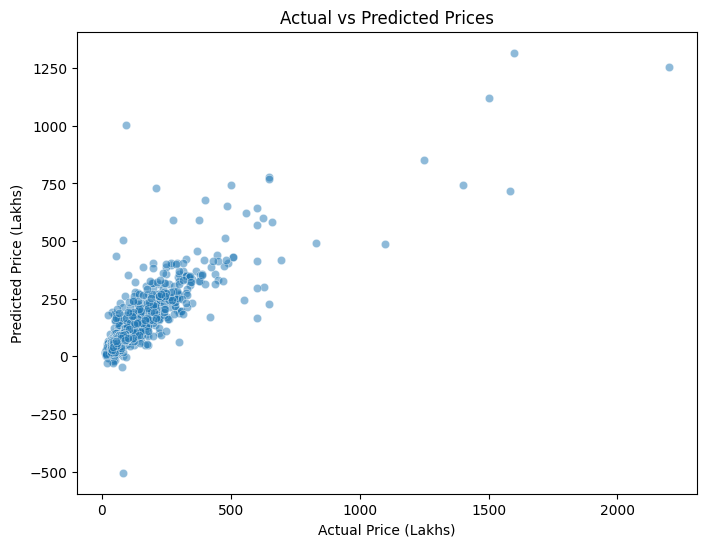

In [81]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=results,
    x='Actual',
    y='Predicted',
    alpha=0.5
)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted Prices')

plt.show()

In [82]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [83]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area_type','location','bhk','total_sqft','bath','balcony']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

In [84]:
y_pred_rf = random_forest_model.predict(X_test)

In [85]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
MAE: 22.034832748087712
RMSE: 60.051164686893564
R²: 0.7353581440615644


In [86]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,25.336590,61.196430,0.725168
1,Random Forest,22.034833,60.051165,0.735358


In [87]:
X = df[
    ['area_type', 'location', 'bhk',
     'total_sqft', 'bath', 'balcony', 'sqft_per_bhk']
]

y = df['price']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [89]:
numerical_features = [
    'bhk',
    'total_sqft',
    'bath',
    'balcony',
    'sqft_per_bhk'
]

In [90]:
categorical_features = ['area_type', 'location']

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

In [92]:
from sklearn.model_selection import train_test_split

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

random_forest_log = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [94]:
random_forest_log.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['area_type','location','bhk',...,'bath','balcony','sqft_per_bhk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of 

In [95]:
y_pred_log = random_forest_log.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_log)

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_log = mean_absolute_error(y_actual, y_pred)
rmse_log = np.sqrt(mean_squared_error(y_actual, y_pred))
r2_log = r2_score(y_actual, y_pred)

print("Log-target Random Forest")
print("MAE:", mae_log)
print("RMSE:", rmse_log)
print("R²:", r2_log)

Log-target Random Forest
MAE: 21.449096964189767
RMSE: 54.34264307159168
R²: 0.7832809049061874


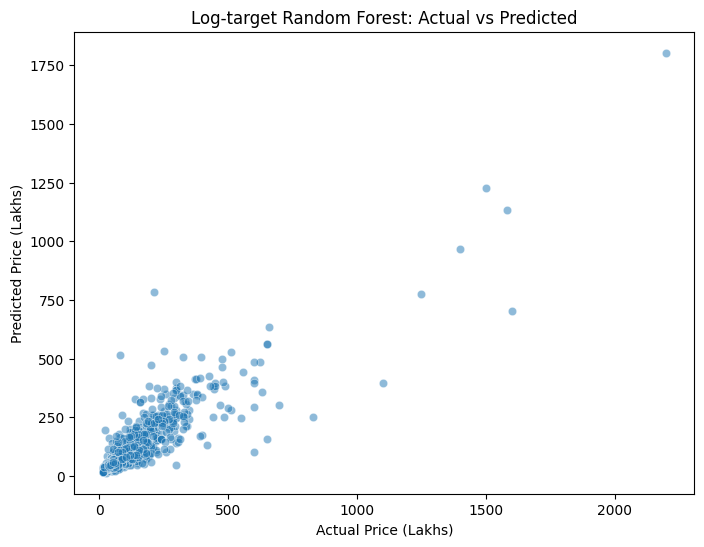

In [97]:
results_log = pd.DataFrame({
    'Actual': y_actual,
    'Predicted': y_pred
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=results_log,
    x='Actual',
    y='Predicted',
    alpha=0.5
)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Log-target Random Forest: Actual vs Predicted')

plt.show()

In [98]:
feature_names = random_forest_log.named_steps['preprocessor'].get_feature_names_out()

importances = random_forest_log.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
958,numerical__total_sqft,0.732774
961,numerical__sqft_per_bhk,0.064081
960,numerical__balcony,0.009323
959,numerical__bath,0.008046
711,categorical__location_Rajaji Nagar,0.007573
207,categorical__location_Chandapura,0.004986
587,categorical__location_Malleshwaram,0.003678
704,categorical__location_Raghuvanahalli,0.003269
535,categorical__location_Koramangala,0.003258
312,categorical__location_Electronic City Phase Ii,0.002984


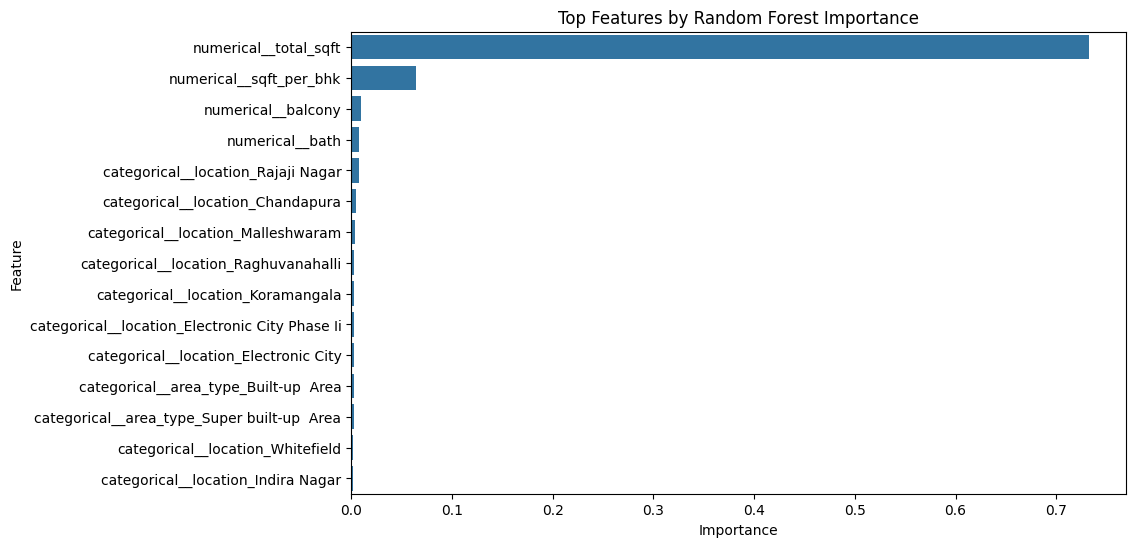

In [99]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature'
)

plt.title('Top Features by Random Forest Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [101]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    random_forest_log,
    X_test,
    y_actual,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [102]:
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

perm_df

,feature,importance
6,sqft_per_bhk,0.026428
3,total_sqft,0.010806
1,location,0.003749
4,bath,0.001586
5,balcony,-0.001052
0,area_type,-0.001121
2,bhk,-0.001381


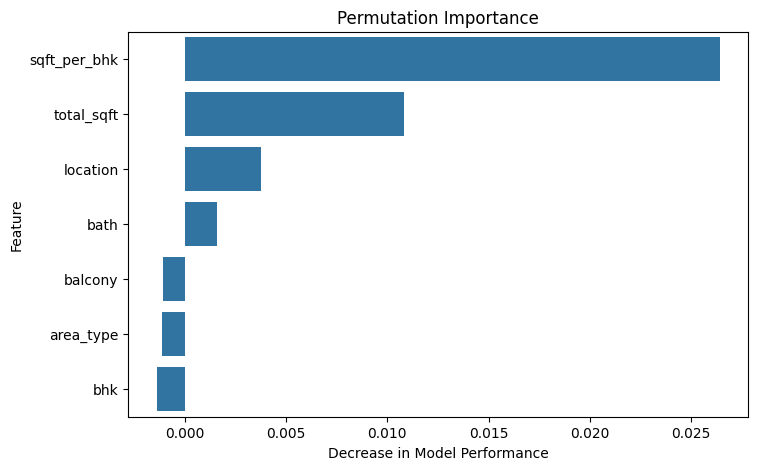

In [103]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=perm_df,
    x='importance',
    y='feature'
)

plt.title('Permutation Importance')
plt.xlabel('Decrease in Model Performance')
plt.ylabel('Feature')

plt.show()

In [104]:
features_a = [
    'area_type',
    'location',
    'bhk',
    'total_sqft',
    'bath',
    'balcony'
]

X_a = df[features_a]
y = df['price']

y_log = np.log1p(y)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y_log,
    test_size=0.2,
    random_state=42
)

In [105]:
categorical_a = ['area_type', 'location']

numerical_a = [
    'bhk',
    'total_sqft',
    'bath',
    'balcony'
]

preprocessor_a = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_a),
    ('numerical', 'passthrough', numerical_a)
])

In [106]:
rf_without_sqb = Pipeline([
    ('preprocessor', preprocessor_a),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [107]:
rf_without_sqb.fit(X_train_a, y_train_a)

pred_log_a = rf_without_sqb.predict(X_test_a)

pred_a = np.expm1(pred_log_a)
actual_a = np.expm1(y_test_a)

In [108]:
mae_a = mean_absolute_error(actual_a, pred_a)
rmse_a = np.sqrt(mean_squared_error(actual_a, pred_a))
r2_a = r2_score(actual_a, pred_a)

print("Without sqft_per_bhk")
print("MAE:", mae_a)
print("RMSE:", rmse_a)
print("R²:", r2_a)

Without sqft_per_bhk
MAE: 21.965439659750864
RMSE: 61.48189753215333
R²: 0.7225976158541291


In [109]:
comparison = pd.DataFrame({
    'Model': [
        'Without sqft_per_bhk',
        'With sqft_per_bhk'
    ],
    'MAE': [
        mae_a,
        mae_log
    ],
    'RMSE': [
        rmse_a,
        rmse_log
    ],
    'R2': [
        r2_a,
        r2_log
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Without sqft_per_bhk,21.965440,61.481898,0.722598
1,With sqft_per_bhk,21.449097,54.342643,0.783281


In [110]:
results = pd.DataFrame({
    'Actual': y_actual,
    'Predicted': y_pred
})

results['Error'] = results['Actual'] - results['Predicted']
results['Absolute_Error'] = abs(results['Error'])

In [111]:
results.sort_values('Absolute_Error', ascending=False).head(20)

,Actual,Predicted,Error,Absolute_Error
8165,1600.0,704.468900,895.531100,895.531100
6781,1100.0,394.664541,705.335459,705.335459
2024,830.0,252.617067,577.382933,577.382933
6592,211.0,784.990769,-573.990769,573.990769
3857,600.0,103.343140,496.656860,496.656860
3539,650.0,159.275777,490.724223,490.724223
743,1250.0,773.764744,476.235256,476.235256
7082,1584.0,1134.570078,449.429922,449.429922
4105,80.0,516.743099,-436.743099,436.743099
9598,1400.0,967.706718,432.293282,432.293282


In [112]:
error_analysis = X_test.copy()

error_analysis['actual_price'] = y_actual
error_analysis['predicted_price'] = y_pred

error_analysis['error'] = (
    error_analysis['actual_price']
    - error_analysis['predicted_price']
)

error_analysis['absolute_error'] = (
    error_analysis['error'].abs()
)

In [113]:
error_analysis.sort_values(
    'absolute_error',
    ascending=False
).head(20)

,area_type,location,bhk,total_sqft,bath,balcony,sqft_per_bhk,actual_price,predicted_price,error,absolute_error
8165,Super built-up Area,Church Street,4.0,11000.0000,4.0,1,2750.000000,1600.0,704.468900,895.531100,895.531100
6781,Built-up Area,Malleshwaram,4.0,4000.0000,4.0,2,1000.000000,1100.0,394.664541,705.335459,705.335459
2024,Built-up Area,Banaswadi,7.0,6150.0000,6.0,1,878.571429,830.0,252.617067,577.382933,577.382933
6592,Built-up Area,Langford Town,4.0,7502.4383,4.0,2,1875.609575,211.0,784.990769,-573.990769,573.990769
3857,Super built-up Area,Domlur,6.0,2400.0000,4.0,1,400.000000,600.0,103.343140,496.656860,496.656860
3539,Built-up Area,Kundalahalli,1.0,2400.0000,1.0,0,2400.000000,650.0,159.275777,490.724223,490.724223
743,Super built-up Area,Cunningham Road,4.0,5270.0000,4.0,3,1317.500000,1250.0,773.764744,476.235256,476.235256
7082,Super built-up Area,Ulsoor,4.0,7200.0000,5.0,2,1800.000000,1584.0,1134.570078,449.429922,449.429922
4105,Super built-up Area,Indranagar 100Ft Road Defence Colony,5.0,5800.0000,5.0,2,1160.000000,80.0,516.743099,-436.743099,436.743099
9598,Super built-up Area,Rajaji Nagar,4.0,6500.0000,5.0,2,1625.000000,1400.0,967.706718,432.293282,432.293282


In [114]:
error_analysis['actual_price_per_sqft'] = (
    error_analysis['actual_price'] * 100000
    / error_analysis['total_sqft']
)

In [115]:
error_analysis.sort_values(
    'absolute_error',
    ascending=False
).head(20)

,area_type,location,bhk,total_sqft,bath,balcony,sqft_per_bhk,actual_price,predicted_price,error,absolute_error,actual_price_per_sqft
8165,Super built-up Area,Church Street,4.0,11000.0000,4.0,1,2750.000000,1600.0,704.468900,895.531100,895.531100,14545.454545
6781,Built-up Area,Malleshwaram,4.0,4000.0000,4.0,2,1000.000000,1100.0,394.664541,705.335459,705.335459,27500.000000
2024,Built-up Area,Banaswadi,7.0,6150.0000,6.0,1,878.571429,830.0,252.617067,577.382933,577.382933,13495.934959
6592,Built-up Area,Langford Town,4.0,7502.4383,4.0,2,1875.609575,211.0,784.990769,-573.990769,573.990769,2812.418997
3857,Super built-up Area,Domlur,6.0,2400.0000,4.0,1,400.000000,600.0,103.343140,496.656860,496.656860,25000.000000
3539,Built-up Area,Kundalahalli,1.0,2400.0000,1.0,0,2400.000000,650.0,159.275777,490.724223,490.724223,27083.333333
743,Super built-up Area,Cunningham Road,4.0,5270.0000,4.0,3,1317.500000,1250.0,773.764744,476.235256,476.235256,23719.165085
7082,Super built-up Area,Ulsoor,4.0,7200.0000,5.0,2,1800.000000,1584.0,1134.570078,449.429922,449.429922,22000.000000
4105,Super built-up Area,Indranagar 100Ft Road Defence Colony,5.0,5800.0000,5.0,2,1160.000000,80.0,516.743099,-436.743099,436.743099,1379.310345
9598,Super built-up Area,Rajaji Nagar,4.0,6500.0000,5.0,2,1625.000000,1400.0,967.706718,432.293282,432.293282,21538.461538


In [116]:
error_analysis['percentage_error'] = (
    error_analysis['absolute_error']
    / error_analysis['actual_price']
) * 100

In [117]:
error_analysis.sort_values(
    'percentage_error',
    ascending=False
).head(20)

,area_type,location,bhk,total_sqft,bath,balcony,sqft_per_bhk,actual_price,predicted_price,error,absolute_error,actual_price_per_sqft,percentage_error
8845,Built-up Area,Raghuvanahalli,1.0,420.0000,1.0,1,420.000000,23.50,195.417066,-171.917066,171.917066,5595.238095,731.561985
4105,Super built-up Area,Indranagar 100Ft Road Defence Colony,5.0,5800.0000,5.0,2,1160.000000,80.00,516.743099,-436.743099,436.743099,1379.310345,545.928874
7961,Super built-up Area,Hegde Nagar,4.0,2600.0000,4.0,3,650.000000,40.00,162.959285,-122.959285,122.959285,1538.461538,307.398211
6592,Built-up Area,Langford Town,4.0,7502.4383,4.0,2,1875.609575,211.00,784.990769,-573.990769,573.990769,2812.418997,272.033540
11277,Built-up Area,Jeevanhalli,4.0,1200.0000,2.0,2,300.000000,35.00,115.946359,-80.946359,80.946359,2916.666667,231.275312
8198,Super built-up Area,Lakshminarayana Pura,3.0,3050.0000,2.0,2,1016.666667,90.00,259.671604,-169.671604,169.671604,2950.819672,188.524005
11426,Super built-up Area,Channasandra Layout,3.0,2400.0000,2.0,3,800.000000,50.00,139.748498,-89.748498,89.748498,2083.333333,179.496995
7077,Super built-up Area,Gollahalli,2.0,1600.0000,2.0,1,800.000000,31.00,86.150485,-55.150485,55.150485,1937.500000,177.904791
11591,Built-up Area,Doddakammanahalli,3.0,2500.0000,4.0,2,833.333333,65.00,171.301654,-106.301654,106.301654,2600.000000,163.541005
5607,Built-up Area,Rajankunte,3.0,4510.0000,4.0,3,1503.333333,200.00,472.387378,-272.387378,272.387378,4434.589800,136.193689


In [118]:
location_counts = df['location'].value_counts()

print("Unique locations:", len(location_counts))
print("Locations with < 10 properties:", (location_counts < 10).sum())
print("Locations with < 20 properties:", (location_counts < 20).sum())

Unique locations: 1031
Locations with < 10 properties: 816
Locations with < 20 properties: 901


In [119]:
location_counts = df['location'].value_counts()

df['location_group'] = df['location'].apply(
    lambda x: x if location_counts[x] >= 10 else 'Other'
)

In [120]:
print("Original locations:", df['location'].nunique())
print("Grouped locations:", df['location_group'].nunique())

Original locations: 1031
Grouped locations: 216


In [121]:
train_location_counts = X_train['location'].value_counts()

frequent_locations = train_location_counts[
    train_location_counts >= 10
].index

In [122]:
X_train_grouped = X_train.copy()
X_test_grouped = X_test.copy()

X_train_grouped['location_group'] = X_train_grouped['location'].where(
    X_train_grouped['location'].isin(frequent_locations),
    'Other'
)

X_test_grouped['location_group'] = X_test_grouped['location'].where(
    X_test_grouped['location'].isin(frequent_locations),
    'Other'
)

In [123]:
X_train_grouped = X_train_grouped.drop(columns=['location'])
X_test_grouped = X_test_grouped.drop(columns=['location'])

In [124]:
print("Train groups:", X_train_grouped['location_group'].nunique())
print("Test groups:", X_test_grouped['location_group'].nunique())

Train groups: 189
Test groups: 185


In [125]:
categorical_features_grouped = [
    'area_type',
    'location_group'
]

numerical_features_grouped = [
    'bhk',
    'total_sqft',
    'bath',
    'balcony',
    'sqft_per_bhk'
]

In [126]:
preprocessor_grouped = ColumnTransformer([
    (
        'categorical',
        OneHotEncoder(handle_unknown='ignore'),
        categorical_features_grouped
    ),
    (
        'numerical',
        'passthrough',
        numerical_features_grouped
    )
])

In [127]:
rf_grouped_location = Pipeline([
    ('preprocessor', preprocessor_grouped),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [128]:
rf_grouped_location.fit(
    X_train_grouped,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['area_type','bhk','total_sqft',...,'balcony','sqft_per_bhk', 'location_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [129]:
pred_grouped_log = rf_grouped_location.predict(
    X_test_grouped
)

pred_grouped = np.expm1(pred_grouped_log)

In [130]:
y_actual = np.expm1(y_test_log)

In [131]:
mae_grouped = mean_absolute_error(
    y_actual,
    pred_grouped
)

rmse_grouped = np.sqrt(
    mean_squared_error(
        y_actual,
        pred_grouped
    )
)

r2_grouped = r2_score(
    y_actual,
    pred_grouped
)

print("Grouped-location Random Forest")
print("MAE:", mae_grouped)
print("RMSE:", rmse_grouped)
print("R²:", r2_grouped)

Grouped-location Random Forest
MAE: 22.191200345653993
RMSE: 56.22561270274091
R²: 0.7680020981495692


In [132]:
#final model
final_features = [
    'area_type',
    'location',
    'bhk',
    'total_sqft',
    'bath',
    'balcony',
    'sqft_per_bhk'
]

X_final = df[final_features]
y_final = df['price']

In [133]:
from sklearn.model_selection import train_test_split

X_dev, X_final_test, y_dev, y_final_test = train_test_split(
    X_final,
    y_final,
    test_size=0.15,
    random_state=42
)

print("Development set:", X_dev.shape)
print("Final test set:", X_final_test.shape)

Development set: (9416, 7)
Final test set: (1662, 7)


In [134]:
categorical_features = [
    'area_type',
    'location'
]

numerical_features = [
    'bhk',
    'total_sqft',
    'bath',
    'balcony',
    'sqft_per_bhk'
]

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_final = ColumnTransformer([
    (
        'categorical',
        OneHotEncoder(handle_unknown='ignore'),
        categorical_features
    ),
    (
        'numerical',
        'passthrough',
        numerical_features
    )
])

In [136]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

base_pipeline = Pipeline([
    (
        'preprocessor',
        preprocessor_final
    ),
    (
        'model',
        RandomForestRegressor(
            random_state=42,
            n_jobs=1
        )
    )
])

final_model = TransformedTargetRegressor(
    regressor=base_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [137]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

mae_scorer = make_scorer(
    mean_absolute_error,
    greater_is_better=False
)

rmse_scorer = make_scorer(
    rmse,
    greater_is_better=False
)

r2_scorer = make_scorer(
    r2_score,
    greater_is_better=True
)

In [138]:
param_distributions = {
    'regressor__model__n_estimators': [200, 300, 400],
    'regressor__model__max_depth': [None, 15, 20, 25],
    'regressor__model__min_samples_leaf': [1, 2, 4],
    'regressor__model__max_features': ['sqrt', 0.5, 0.8]
}

In [139]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=mae_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [140]:
search.fit(X_dev, y_dev)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__max_depth': [None, 15, ...], 'regressor__model__max_features': ['sqrt', 0.5, ...], 'regressor__model__min_samples_leaf': [1, 2, ...], 'regressor__model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations othe

In [141]:
print("Best parameters:")
print(search.best_params_)

Best parameters:
{'regressor__model__n_estimators': 300, 'regressor__model__min_samples_leaf': 1, 'regressor__model__max_features': 0.5, 'regressor__model__max_depth': None}


In [142]:
print("Best CV MAE:", -search.best_score_)

Best CV MAE: 22.052450665452323


In [143]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    search.best_estimator_,
    X_dev,
    y_dev,
    cv=5,
    scoring={
        'MAE': mae_scorer,
        'RMSE': rmse_scorer,
        'R2': r2_scorer
    },
    n_jobs=-1
)

In [146]:
print(
    "CV MAE:",
    -cv_results['test_MAE'].mean(),
    "±",
    cv_results['test_MAE'].std()
)

print(
    "CV RMSE:",
    -cv_results['test_RMSE'].mean(),
    "±",
    cv_results['test_RMSE'].std()
)

print(
    "CV R²:",
    cv_results['test_R2'].mean(),
    "±",
    cv_results['test_R2'].std()
)

CV MAE: 21.246127720058613 ± 0.7723513398730719
CV RMSE: 60.6443287774939 ± 8.421799403379012
CV R²: 0.7062696721997495 ± 0.039120971602644244


In [147]:
best_model = search.best_estimator_

final_predictions = best_model.predict(X_final_test)

In [148]:
final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_rmse = rmse(
    y_final_test,
    final_predictions
)

final_r2 = r2_score(
    y_final_test,
    final_predictions
)

print("FINAL TEST RESULTS")
print("------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL TEST RESULTS
------------------
MAE : 20.89102063294294
RMSE: 56.73390676407776
R²  : 0.7605472137481518


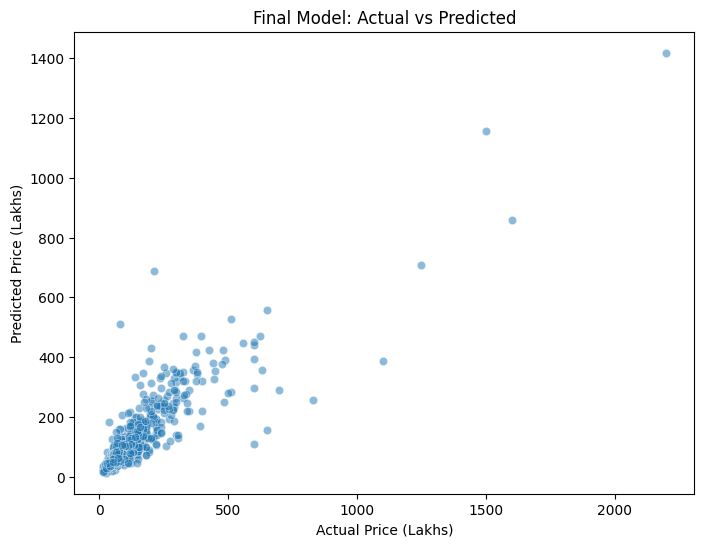

In [149]:
final_results = pd.DataFrame({
    'Actual': y_final_test.values,
    'Predicted': final_predictions
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=final_results,
    x='Actual',
    y='Predicted',
    alpha=0.5
)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Final Model: Actual vs Predicted')

plt.show()

In [150]:
import joblib

joblib.dump(
    best_model,
    'bengaluru_house_price_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [151]:
df.to_csv("bengaluru_house_clean.csv", index=False)

print("Saved!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Saved!
Rows: 11078
Columns: ['area_type', 'location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft', 'sqft_per_bhk', 'location_group']


In [152]:
import os

os.makedirs("eda", exist_ok=True)

In [153]:
bhk_summary = df.groupby('bhk').agg(
    property_count=('price', 'count'),
    median_price=('price', 'median'),
    median_sqft=('total_sqft', 'median'),
    median_price_per_sqft=('price_per_sqft', 'median')
).reset_index()

bhk_summary.to_csv("eda/bhk_summary.csv", index=False)

bhk_summary

,bhk,property_count,median_price,median_sqft,median_price_per_sqft
0,1.0,571,33.000,645.0,5000.000000
1,2.0,5182,53.000,1141.0,4740.167567
2,3.0,4360,86.475,1590.0,5481.680687
3,4.0,762,220.000,3000.0,7276.059409
4,5.0,100,216.500,3275.0,6611.584130
5,6.0,51,165.000,3000.0,5000.000000
6,7.0,29,150.000,3600.0,4677.419355
7,8.0,11,145.000,3300.0,4333.333333
8,9.0,9,200.000,4600.0,4062.500000
9,10.0,3,200.000,7200.0,4000.000000


In [154]:
location_stats = df.groupby('location').agg(
    property_count=('price', 'count'),
    median_price=('price', 'median'),
    median_sqft=('total_sqft', 'median'),
    median_price_per_sqft=('price_per_sqft', 'median')
).reset_index()

In [155]:
location_stats.to_csv("eda/location_stats.csv", index=False)

In [156]:
top_locations = (
    location_stats[location_stats['property_count'] >= 20]
    .sort_values('median_price', ascending=False)
    .head(20)
)

top_locations.to_csv(
    "eda/top_locations_by_price.csv",
    index=False
)

top_locations

,location,property_count,median_price,median_sqft,median_price_per_sqft
629,Malleshwaram,50,272.5,2215.0,12455.009698
768,Rajaji Nagar,89,251.5,1776.0,13519.222645
438,Iblur Village,25,220.0,2987.5,7264.296754
334,Frazer Town,32,210.0,2039.5,9908.689373
713,Old Airport Road,33,194.0,2690.0,7397.769517
400,Hebbal Kempapura,26,167.5,1757.5,9003.267974
440,Indira Nagar,32,164.0,1575.0,10196.687371
424,Hosakerehalli,29,153.0,2376.0,8420.473308
926,Thigalarapalya,61,150.0,2072.0,7377.049180
187,Binny Pete,20,148.5,1440.5,8472.781376


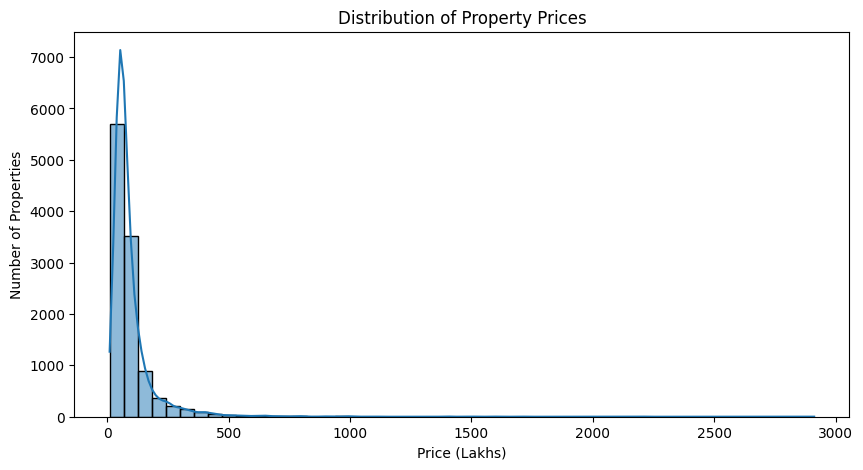

In [157]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Property Prices')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Number of Properties')

plt.savefig(
    "eda/price_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

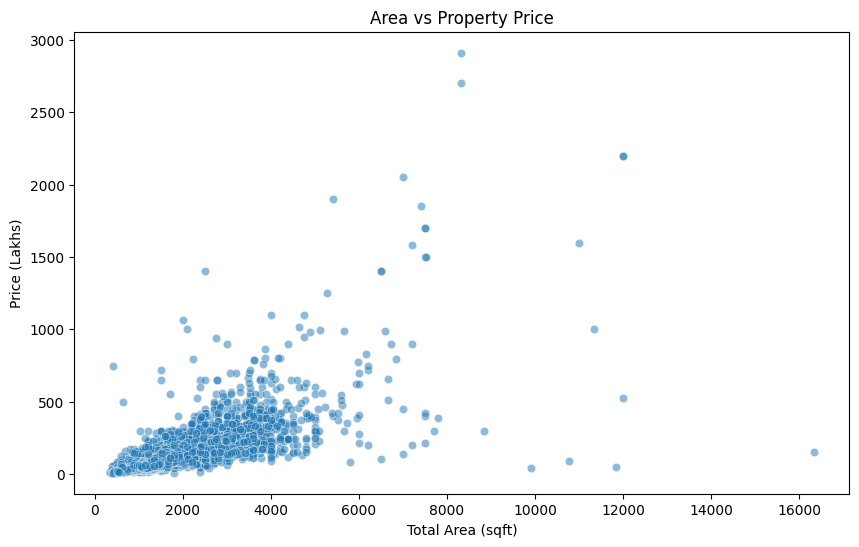

In [158]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='total_sqft',
    y='price',
    alpha=0.5
)

plt.title('Area vs Property Price')
plt.xlabel('Total Area (sqft)')
plt.ylabel('Price (Lakhs)')

plt.savefig(
    "eda/area_vs_price.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

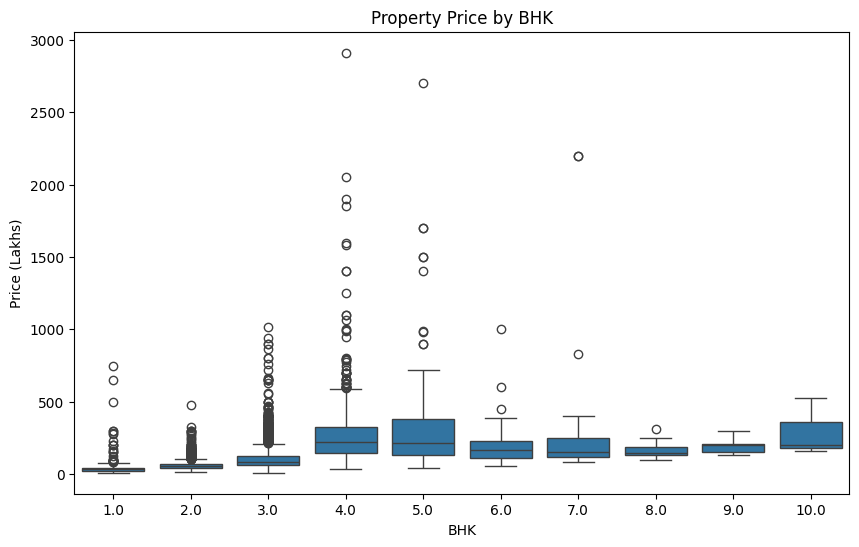

In [159]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='bhk',
    y='price'
)

plt.title('Property Price by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')

plt.savefig(
    "eda/bhk_vs_price.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

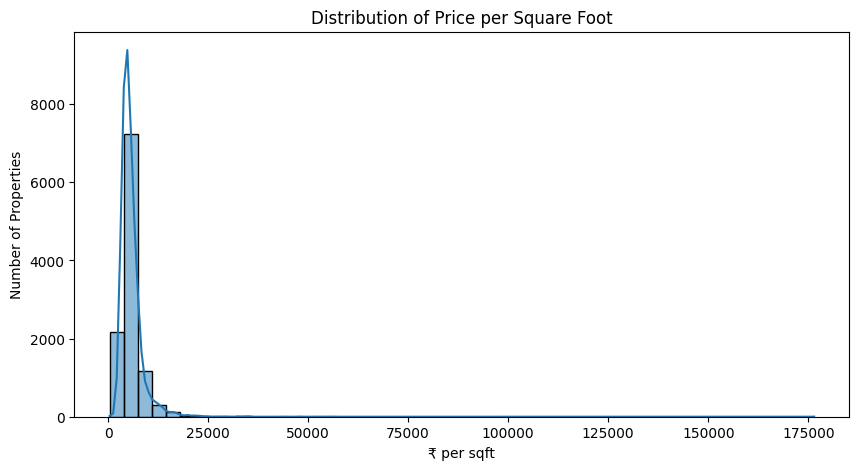

In [160]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['price_per_sqft'],
    bins=50,
    kde=True
)

plt.title('Distribution of Price per Square Foot')
plt.xlabel('₹ per sqft')
plt.ylabel('Number of Properties')

plt.savefig(
    "eda/price_per_sqft_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [161]:
eda_summary = {
    "total_properties": len(df),
    "unique_locations": df['location'].nunique(),
    "median_price_lakhs": df['price'].median(),
    "median_area_sqft": df['total_sqft'].median(),
    "median_bhk": df['bhk'].median(),
    "median_price_per_sqft": df['price_per_sqft'].median()
}

pd.Series(eda_summary).to_csv(
    "eda/eda_summary.csv"
)

pd.Series(eda_summary)

total_properties         11078.000000
unique_locations          1031.000000
median_price_lakhs          65.000000
median_area_sqft          1290.000000
median_bhk                   2.000000
median_price_per_sqft     5107.207621
dtype: float64